In [1]:
# STEP 1: Install dependencies
!pip install torch torchvision torchaudio
!pip install torch-scatter torch-sparse torch-geometric -f https://data.pyg.org/whl/torch-2.0.0+cpu.html

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 113.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjit

In [2]:
# STEP 2: Import packages
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import torch
from torch_geometric.data import Data


/usr/local/lib/python3.11/dist-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_scatter/_version_cpu.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/usr/local/lib/python3.11/dist-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_sparse/_version_cpu.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


In [50]:
# STEP 3: Upload your cleaned CSV file
from google.colab import files
uploaded = files.upload()  # upload 'clean_listings_32827.csv'


Saving rentcast_sample_with_estimates.csv to rentcast_sample_with_estimates.csv


In [4]:
!rm -r merged_file.csv
!ls


rm: cannot remove 'merged_file.csv': No such file or directory
clean_listings_32789.csv  clean_listings_32808.csv  clean_listings_32827.csv
clean_listings_32801.csv  clean_listings_32809.csv  clean_listings_32835.csv
clean_listings_32803.csv  clean_listings_32811.csv  clean_listings_32839.csv
clean_listings_32804.csv  clean_listings_32812.csv  sample_data
clean_listings_32805.csv  clean_listings_32819.csv
clean_listings_32806.csv  clean_listings_32822.csv


In [5]:
import pandas as pd
import glob

# Get a list of all CSV files in the current directory
csv_files = glob.glob('*.csv')
print(f"Found {len(csv_files)} CSV files.\n")

# Create an empty list to store individual DataFrames
all_df = []

# Loop through each CSV file and track number of rows
for file in csv_files:
    df = pd.read_csv(file)
    num_rows = len(df)
    print(f"{file}: {num_rows} rows")
    all_df.append(df)

# Concatenate all DataFrames in the list into a single DataFrame
merged_df = pd.concat(all_df, ignore_index=True)

# Save the merged DataFrame to a new CSV file
merged_df.to_csv('merged_file.csv', index=False)

print(f"\nMerged DataFrame has {len(merged_df)} rows.")


Found 15 CSV files.

clean_listings_32801.csv: 1583 rows
clean_listings_32812.csv: 2254 rows
clean_listings_32804.csv: 1874 rows
clean_listings_32803.csv: 1886 rows
clean_listings_32827.csv: 2294 rows
clean_listings_32805.csv: 1021 rows
clean_listings_32809.csv: 1170 rows
clean_listings_32806.csv: 2339 rows
clean_listings_32819.csv: 2728 rows
clean_listings_32839.csv: 1978 rows
clean_listings_32789.csv: 2445 rows
clean_listings_32835.csv: 3330 rows
clean_listings_32808.csv: 2758 rows
clean_listings_32822.csv: 3825 rows
clean_listings_32811.csv: 2324 rows

Merged DataFrame has 33809 rows.


In [23]:
# STEP 4: Load and inspect the data
df = merged_df
print(df.shape)
df.head()


(33809, 21)


,id,formattedaddress,addressline1,addressline2,city,state,zipcode,county,latitude,longitude,...,bedrooms,bathrooms,squarefootage,lotsize,yearbuilt,status,price,listeddate,daysonmarket,log_price
0,"530-E-Central-Blvd,-Apt-1002,-Orlando,-FL-32801","530 E Central Blvd, Apt 1002, Orlando, FL 32801",530 E Central Blvd,Apt 1002,Orlando,FL,32801,Orange,28.541908,-81.370161,...,2.0,2.0,1304.0,13504.0,1985.0,Active,315000,2023-09-25T00:00:00.000Z,561,12.660331
1,"155-S-Court-Ave,-Unit-2107,-Orlando,-FL-32801","155 S Court Ave, Unit 2107, Orlando, FL 32801",155 S Court Ave,Unit 2107,Orlando,FL,32801,Orange,28.540891,-81.377695,...,1.0,1.0,730.0,3668.0,2007.0,Active,245000,2023-05-22T00:00:00.000Z,687,12.409018
2,"155-S-Court-Ave,-Unit-1704,-Orlando,-FL-32801","155 S Court Ave, Unit 1704, Orlando, FL 32801",155 S Court Ave,Unit 1704,Orlando,FL,32801,Orange,28.540891,-81.377695,...,1.0,1.0,715.0,3668.0,2007.0,Active,225000,2024-03-21T00:00:00.000Z,383,12.323860
3,"304-E-South-St,-Unit-4027,-Orlando,-FL-32801","304 E South St, Unit 4027, Orlando, FL 32801",304 E South St,Unit 4027,Orlando,FL,32801,Orange,28.537812,-81.375310,...,1.0,1.0,744.0,94090.0,2002.0,Active,158000,2024-03-03T00:00:00.000Z,401,11.970357
4,"155-S-Court-Ave,-Unit-1804,-Orlando,-FL-32801","155 S Court Ave, Unit 1804, Orlando, FL 32801",155 S Court Ave,Unit 1804,Orlando,FL,32801,Orange,28.540891,-81.377695,...,1.0,1.0,715.0,3668.0,2007.0,Active,189900,2024-04-28T00:00:00.000Z,345,12.154258


In [24]:
if df.isnull().values.any():
    print("⚠️ There are missing values in the DataFrame.")
else:
    print("✅ No missing values found in the DataFrame.")
print("Total missing values in DataFrame:", df.isnull().sum().sum())
print("Columns with missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


⚠️ There are missing values in the DataFrame.
Total missing values in DataFrame: 22028
Columns with missing values:
addressline2    21732
county              2
propertytype      277
bathrooms          17
dtype: int64


In [25]:
print("Top Property Types:\n", df['propertytype'].value_counts(dropna=False))
nan_propertytype_rows = df[df['propertytype'].isnull()]
print(f"{len(nan_propertytype_rows)} rows with missing propertytype\n")


Top Property Types:
 propertytype
single_family    18796
condo            12167
townhouse         1257
manufactured       634
multi-family       437
NaN                277
apartment          155
land                86
Name: count, dtype: int64
277 rows with missing propertytype



In [26]:
# Define bounding box for main region (adjust as needed)
lat_min, lat_max = 28.2, 28.8
lon_min, lon_max = -81.6, -81.1

# Apply geographic filter to keep only points within the bounding box
mask = (df['latitude'] >= lat_min) & (df['latitude'] <= lat_max) & \
       (df['longitude'] >= lon_min) & (df['longitude'] <= lon_max)

df_filtered = df[mask].reset_index(drop=True)
print(f"Original data: {len(df)}, After filtering: {len(df_filtered)}")



Original data: 33809, After filtering: 33803


In [27]:
df=df_filtered
print(f"Original data: {len(df)}")
df = df[df['propertytype'] != 'land']
df = df[df['propertytype'] != 'manufactured']
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())
print("Top Property Types:\n", df['propertytype'].value_counts(dropna=False))
nan_propertytype_rows = df[df['propertytype'].isnull()]
print(f"{len(nan_propertytype_rows)} rows with missing propertytype\n")

Original data: 33803
Top Property Types:
 propertytype
single_family    18794
condo            12166
townhouse         1256
multi-family       436
NaN                276
apartment          155
Name: count, dtype: int64
276 rows with missing propertytype



In [28]:
print(df.shape)
df.head()

(33083, 21)


,id,formattedaddress,addressline1,addressline2,city,state,zipcode,county,latitude,longitude,...,bedrooms,bathrooms,squarefootage,lotsize,yearbuilt,status,price,listeddate,daysonmarket,log_price
0,"530-E-Central-Blvd,-Apt-1002,-Orlando,-FL-32801","530 E Central Blvd, Apt 1002, Orlando, FL 32801",530 E Central Blvd,Apt 1002,Orlando,FL,32801,Orange,28.541908,-81.370161,...,2.0,2.0,1304.0,13504.0,1985.0,Active,315000,2023-09-25T00:00:00.000Z,561,12.660331
1,"155-S-Court-Ave,-Unit-2107,-Orlando,-FL-32801","155 S Court Ave, Unit 2107, Orlando, FL 32801",155 S Court Ave,Unit 2107,Orlando,FL,32801,Orange,28.540891,-81.377695,...,1.0,1.0,730.0,3668.0,2007.0,Active,245000,2023-05-22T00:00:00.000Z,687,12.409018
2,"155-S-Court-Ave,-Unit-1704,-Orlando,-FL-32801","155 S Court Ave, Unit 1704, Orlando, FL 32801",155 S Court Ave,Unit 1704,Orlando,FL,32801,Orange,28.540891,-81.377695,...,1.0,1.0,715.0,3668.0,2007.0,Active,225000,2024-03-21T00:00:00.000Z,383,12.323860
3,"304-E-South-St,-Unit-4027,-Orlando,-FL-32801","304 E South St, Unit 4027, Orlando, FL 32801",304 E South St,Unit 4027,Orlando,FL,32801,Orange,28.537812,-81.375310,...,1.0,1.0,744.0,94090.0,2002.0,Active,158000,2024-03-03T00:00:00.000Z,401,11.970357
4,"155-S-Court-Ave,-Unit-1804,-Orlando,-FL-32801","155 S Court Ave, Unit 1804, Orlando, FL 32801",155 S Court Ave,Unit 1804,Orlando,FL,32801,Orange,28.540891,-81.377695,...,1.0,1.0,715.0,3668.0,2007.0,Active,189900,2024-04-28T00:00:00.000Z,345,12.154258


In [29]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Step 0: Make a copy (optional)
df_copy = df.copy()

# Step 1: Separate rows with and without missing propertytype
df_known = df_copy[df_copy['propertytype'].notnull()]
df_unknown = df_copy[df_copy['propertytype'].isnull()]

# Step 2: Encode propertytype as numeric labels
le = LabelEncoder()
df_known['propertytype_encoded'] = le.fit_transform(df_known['propertytype'])

# Step 3: Choose features to use for prediction (drop address fields etc.)
features = ['bedrooms', 'bathrooms', 'squarefootage', 'yearbuilt', 'price']

# Optional: ensure no NaNs in predictor columns
df_known = df_known.dropna(subset=features)

# Step 4: Train/test split (just for sanity check)
X = df_known[features]
y = df_known['propertytype_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Accuracy on held-out set (optional)
print("Model accuracy on known propertytype test data:", clf.score(X_test, y_test))

# Step 5: Prepare and predict for missing rows
df_unknown_clean = df_unknown.dropna(subset=features)
X_missing = df_unknown_clean[features]

predicted_types = clf.predict(X_missing)
decoded_types = le.inverse_transform(predicted_types)

# Step 6: Assign predictions back to the missing rows
df.loc[df_unknown_clean.index, 'propertytype'] = decoded_types

# Confirm:
print(f"Remaining NaNs in propertytype: {df['propertytype'].isnull().sum()}")


<ipython-input-29-c67ca385942b>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_known['propertytype_encoded'] = le.fit_transform(df_known['propertytype'])


Model accuracy on known propertytype test data: 0.9076501066747943
Remaining NaNs in propertytype: 0


In [30]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")
print(df.isnull().sum()[df.isnull().sum() > 0])


Number of duplicate rows: 0
addressline2    21259
county              2
dtype: int64


In [31]:
# Assuming your dataset is a pandas DataFrame named df
# Replace with actual name if different

categorical_columns = df.select_dtypes(include=['object', 'category']).columns

print("Categorical columns and their unique values:\n")
for col in categorical_columns:
    print(f"{col}:")
    print(df[col].unique())
    print("-" * 40)


Categorical columns and their unique values:

id:
['530-E-Central-Blvd,-Apt-1002,-Orlando,-FL-32801'
 '155-S-Court-Ave,-Unit-2107,-Orlando,-FL-32801'
 '155-S-Court-Ave,-Unit-1704,-Orlando,-FL-32801' ...
 '5237-Vineland-Rd,-Unit-103,-Orlando,-FL-32811'
 '4304-S-Kirkman-Rd,-Apt-107,-Orlando,-FL-32811'
 '5253-Brook-Ct,-Unit-244,-Orlando,-FL-32811']
----------------------------------------
formattedaddress:
['530 E Central Blvd, Apt 1002, Orlando, FL 32801'
 '155 S Court Ave, Unit 2107, Orlando, FL 32801'
 '155 S Court Ave, Unit 1704, Orlando, FL 32801' ...
 '5237 Vineland Rd, Unit 103, Orlando, FL 32811'
 '4304 S Kirkman Rd, Apt 107, Orlando, FL 32811'
 '5253 Brook Ct, Unit 244, Orlando, FL 32811']
----------------------------------------
addressline1:
['530 E Central Blvd' '155 S Court Ave' '304 E South St' ...
 '2848 Santana Ave' '5237 Vineland Rd' '5253 Brook Ct']
----------------------------------------
addressline2:
['Apt 1002' 'Unit 2107' 'Unit 1704' ... 'Unit 402B1' 'Apt 2307' 'Uni

In [32]:
def one_hot_property_type(value, categories):
    return np.array([1.0 if value == cat else 0.0 for cat in categories], dtype=np.float32)
# Step 0: Define consistent property type categories from the data
property_categories = sorted(df['propertytype'].dropna().unique().tolist())

# Step 1: Define the original numerical features
features = ['bedrooms', 'bathrooms', 'squarefootage', 'lotsize', 'yearbuilt']
X_num = df[features].values.astype(np.float32)

# Step 2: One-hot encode 'propertytype' using stable categories
X_cat = np.array([one_hot_property_type(ptype, property_categories) for ptype in df['propertytype']], dtype=np.float32)

# Step 3: Combine numerical and categorical features
X = np.hstack([X_num, X_cat])

# Step 4: Targets and coordinates
y = df['log_price'].values.astype(np.float32)
coords = df[['latitude', 'longitude']].values.astype(np.float64)



In [33]:
print("Raw numeric input:", X_num)
print("Any NaNs in raw_numeric?", np.isnan(X_num).any())


Raw numeric input: [[2.0000e+00 2.0000e+00 1.3040e+03 1.3504e+04 1.9850e+03]
 [1.0000e+00 1.0000e+00 7.3000e+02 3.6680e+03 2.0070e+03]
 [1.0000e+00 1.0000e+00 7.1500e+02 3.6680e+03 2.0070e+03]
 ...
 [2.0000e+00 2.0000e+00 1.0480e+03 7.0350e+03 1.9880e+03]
 [2.0000e+00 2.0000e+00 9.9600e+02 7.0350e+03 1.9880e+03]
 [2.0000e+00 2.5000e+00 1.2850e+03 7.0350e+03 1.9880e+03]]
Any NaNs in raw_numeric? False


In [34]:
print("X shape:", X.shape)
print("First 5 rows of X:\n", X[:5])

print("\ny shape:", y.shape)
print("First 5 values of y:", y[:5])



X shape: (33083, 10)
First 5 rows of X:
 [[2.0000e+00 2.0000e+00 1.3040e+03 1.3504e+04 1.9850e+03 0.0000e+00
  1.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.0000e+00 1.0000e+00 7.3000e+02 3.6680e+03 2.0070e+03 0.0000e+00
  1.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.0000e+00 1.0000e+00 7.1500e+02 3.6680e+03 2.0070e+03 0.0000e+00
  1.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.0000e+00 1.0000e+00 7.4400e+02 9.4090e+04 2.0020e+03 0.0000e+00
  1.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.0000e+00 1.0000e+00 7.1500e+02 3.6680e+03 2.0070e+03 0.0000e+00
  1.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00]]

y shape: (33083,)
First 5 values of y: [12.660331 12.409018 12.32386  11.970357 12.154258]


In [35]:
# STEP 6: Compute k-nearest neighbors using Haversine distance
coords_rad = np.radians(coords)
k = 8

nbrs = NearestNeighbors(n_neighbors=k + 1, algorithm='ball_tree', metric='haversine').fit(coords_rad)
distances, indices = nbrs.kneighbors(coords_rad)

edge_index_list = []
edge_attr_list = []

for i, neighbors in enumerate(indices):
    for j, neighbor in enumerate(neighbors[1:]):  # skip self
        edge_index_list.append([i, neighbor])
        edge_attr_list.append([distances[i][j + 1]])  # in radians


In [36]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import torch

# Step 1: Prepare ZIP code mapping
zip_codes = df['zipcode'].astype(str)
zip_code_categories = sorted(zip_codes.unique())
zip_code_to_idx = {z: i for i, z in enumerate(zip_code_categories)}
df['zip_idx'] = zip_codes.map(zip_code_to_idx)

# Step 2: Extract numeric features
X_numeric = df[['bedrooms', 'bathrooms', 'squarefootage', 'lotsize', 'yearbuilt']].values.astype(np.float32)

# Step 3: One-hot property type
X_propertytype = np.array([
    one_hot_property_type(ptype, property_categories)
    for ptype in df['propertytype']
], dtype=np.float32)

# Step 4: Scale numeric features
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)

# Step 5: Prepare x_main (without zip)
X_combined = np.concatenate([X_numeric_scaled, X_propertytype], axis=1)
x_main = torch.tensor(X_combined, dtype=torch.float32)

# Step 6: Zip code indices tensor
zip_idx = torch.tensor(df['zip_idx'].values, dtype=torch.long)

# Step 7: Targets
y = torch.tensor(df['log_price'].values, dtype=torch.float32)


In [37]:
import torch
from torch_geometric.data import Data

# Convert edge_index_list to tensor (shape [2, num_edges])
edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()

# Convert edge_attr_list to tensor (shape [num_edges, 1])
edge_attr = torch.tensor(edge_attr_list, dtype=torch.float)

# Now create the PyG Data object
data = Data(x=x_main, edge_index=edge_index, edge_attr=edge_attr, y=y)


In [38]:
print("NaNs in x:", torch.isnan(data.x).sum().item())
print("Infs in x:", torch.isinf(data.x).sum().item())
print("NaNs in y:", torch.isnan(data.y).sum().item())
print("Infs in y:", torch.isinf(data.y).sum().item())
print("y stats: min =", data.y.min().item(), ", max =", data.y.max().item())
print("NaNs in edge_attr:", torch.isnan(data.edge_attr).sum().item())
print("Infs in edge_attr:", torch.isinf(data.edge_attr).sum().item())
print("x mean:", data.x.mean().item())
print("x std:", data.x.std().item())


NaNs in x: 0
Infs in x: 0
NaNs in y: 0
Infs in y: 0
y stats: min = 8.517393112182617 , max = 16.676910400390625
NaNs in edge_attr: 0
Infs in edge_attr: 0
x mean: 0.10000000149011612
x std: 0.768115758895874


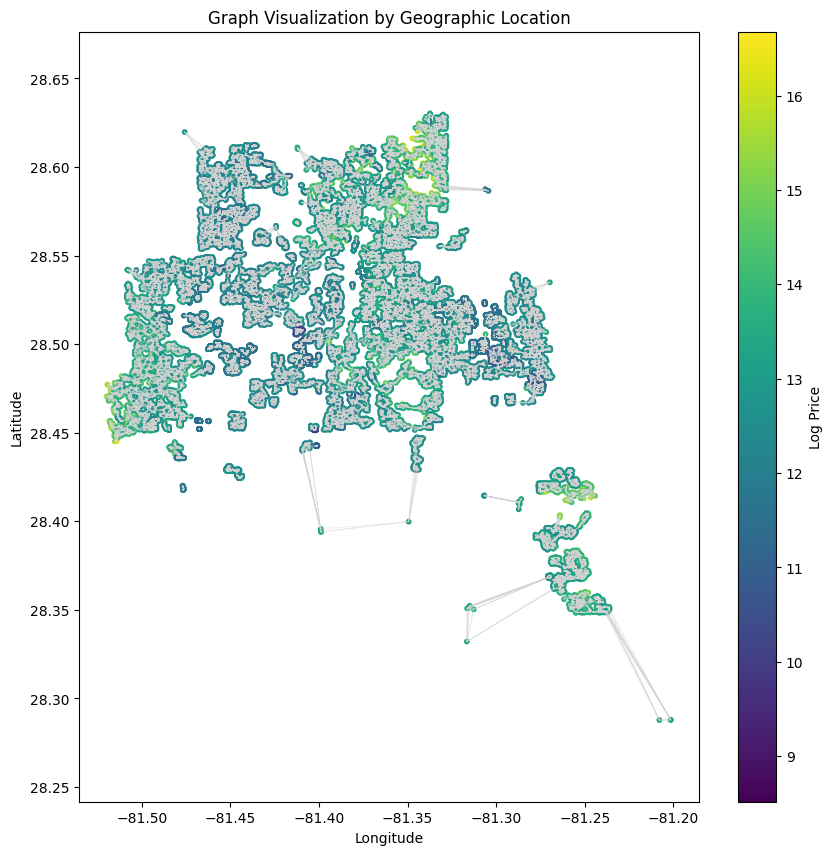

In [39]:
import matplotlib.pyplot as plt

# Get positions
pos = df[['longitude', 'latitude']].values

# Get edge list
edges = data.edge_index.numpy()

plt.figure(figsize=(10, 10))

# Plot edges
for i in range(edges.shape[1]):
    src, tgt = edges[:, i]
    x_coords = [pos[src][0], pos[tgt][0]]
    y_coords = [pos[src][1], pos[tgt][1]]
    plt.plot(x_coords, y_coords, color='lightgray', linewidth=0.5, alpha=0.5)

# Plot nodes
plt.scatter(pos[:, 0], pos[:, 1], c=df['log_price'], cmap='viridis', s=10)
plt.colorbar(label='Log Price')
plt.title("Graph Visualization by Geographic Location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis('equal')
plt.show()


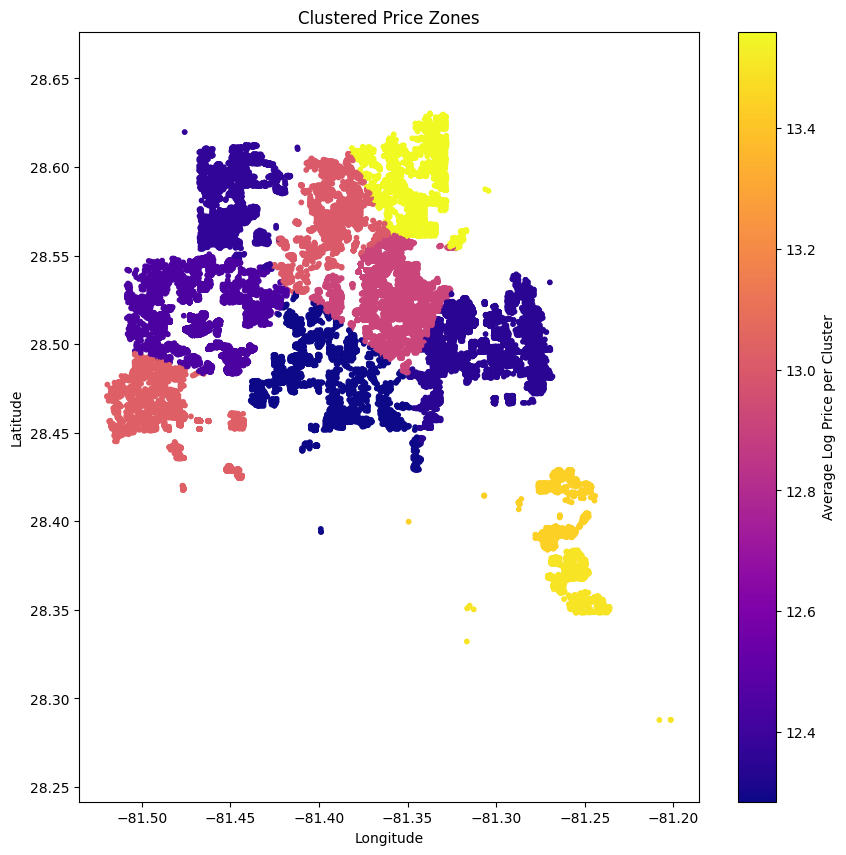

In [40]:
from sklearn.cluster import KMeans

# Cluster by location (can add price or features too)
coords = df_filtered[['longitude', 'latitude']].values
kmeans = KMeans(n_clusters=10, random_state=0).fit(coords)
df_filtered['price_cluster'] = kmeans.labels_

# Compute average price per cluster
cluster_avg = df_filtered.groupby('price_cluster')['log_price'].mean()

# Map to colors
cluster_colors = df_filtered['price_cluster'].map(cluster_avg)
plt.figure(figsize=(10, 10))
plt.scatter(df_filtered['longitude'], df_filtered['latitude'], c=cluster_colors, cmap='plasma', s=10)
plt.colorbar(label='Average Log Price per Cluster')
plt.title("Clustered Price Zones")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis('equal')
plt.show()


In [41]:
print("NaNs in x:", torch.isnan(data.x).sum().item())
print("Infs in x:", torch.isinf(data.x).sum().item())
print("NaNs in y:", torch.isnan(data.y).sum().item())
print("Infs in y:", torch.isinf(data.y).sum().item())
print("y stats: min =", data.y.min().item(), ", max =", data.y.max().item())
print("NaNs in edge_attr:", torch.isnan(data.edge_attr).sum().item())
print("Infs in edge_attr:", torch.isinf(data.edge_attr).sum().item())
print("x mean:", data.x.mean().item())
print("x std:", data.x.std().item())


NaNs in x: 0
Infs in x: 0
NaNs in y: 0
Infs in y: 0
y stats: min = 8.517393112182617 , max = 16.676910400390625
NaNs in edge_attr: 0
Infs in edge_attr: 0
x mean: 0.10000000149011612
x std: 0.768115758895874


In [42]:
from torch_geometric.utils import train_test_split_edges

# Split into training / val / test masks
num_nodes = data.num_nodes
perm = torch.randperm(num_nodes)
train_idx = perm[:int(0.8 * num_nodes)]
test_idx  = perm[int(0.8 * num_nodes):]

data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.train_mask[train_idx] = True

data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.test_mask[test_idx] = True


In [43]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCNRegressor(nn.Module):
    def __init__(self, in_channels, hidden_channels, zip_vocab_size, zip_embed_dim=8):
        super().__init__()

        # Embedding layer for zip code
        self.zip_embed = nn.Embedding(zip_vocab_size, zip_embed_dim)

        # GCN layers
        self.conv1 = GCNConv(in_channels + zip_embed_dim, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)

        # Linear layers after GCN
        self.lin1 = nn.Linear(hidden_channels, hidden_channels // 2)
        self.lin2 = nn.Linear(hidden_channels // 2, 1)

        # Dropout for regularization
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x, zip_codes, edge_index):
        # Embed the zip codes and concatenate to input features
        zip_embedded = self.zip_embed(zip_codes)
        x = torch.cat([x, zip_embedded], dim=1)

        # GCN layers with ReLU
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))

        # Dropout
        x = self.dropout(x)

        # Linear layers
        x = F.relu(self.lin1(x))
        x = self.lin2(x)

        return x.squeeze()


In [44]:
model = GCNRegressor(
    in_channels=x_main.shape[1],
    hidden_channels=64,
    zip_vocab_size=len(zip_code_to_idx),
    zip_embed_dim=8
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
loss_fn = nn.MSELoss()

for epoch in range(500):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    out = model(x_main, zip_idx, data.edge_index)

    # Training loss
    loss = loss_fn(out[data.train_mask], y[data.train_mask])
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        model.eval()
        with torch.no_grad():
            test_out = model(x_main, zip_idx, data.edge_index)
            test_loss = loss_fn(test_out[data.test_mask], y[data.test_mask])
            print(f'Epoch {epoch}, Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}')


Epoch 0, Train Loss: 162.7146, Test Loss: 159.6030
Epoch 10, Train Loss: 70.9052, Test Loss: 52.1674
Epoch 20, Train Loss: 26.6222, Test Loss: 21.9147
Epoch 30, Train Loss: 19.1834, Test Loss: 16.1280
Epoch 40, Train Loss: 13.2902, Test Loss: 11.5306
Epoch 50, Train Loss: 11.8964, Test Loss: 10.2906
Epoch 60, Train Loss: 10.4360, Test Loss: 9.1084
Epoch 70, Train Loss: 9.4077, Test Loss: 8.0160
Epoch 80, Train Loss: 8.0611, Test Loss: 6.7276
Epoch 90, Train Loss: 6.5083, Test Loss: 5.2663
Epoch 100, Train Loss: 4.8156, Test Loss: 3.5966
Epoch 110, Train Loss: 3.2581, Test Loss: 2.0987
Epoch 120, Train Loss: 2.0858, Test Loss: 0.9858
Epoch 130, Train Loss: 1.5010, Test Loss: 0.4447
Epoch 140, Train Loss: 1.3573, Test Loss: 0.2751
Epoch 150, Train Loss: 1.2789, Test Loss: 0.2558
Epoch 160, Train Loss: 1.2242, Test Loss: 0.2362
Epoch 170, Train Loss: 1.1932, Test Loss: 0.2223
Epoch 180, Train Loss: 1.1596, Test Loss: 0.2126
Epoch 190, Train Loss: 1.1509, Test Loss: 0.2034
Epoch 200, Train

In [45]:
import torch
import torch.nn.functional as F
from torch.nn import Linear, Embedding
from torch_geometric.nn import TransformerConv

class PD_TGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels=64, heads=2, dropout=0.1,
                 zip_vocab_size=None, zip_embed_dim=None):
        super(PD_TGCN, self).__init__()

        if zip_vocab_size is not None and zip_embed_dim is not None:
            self.zip_embed = Embedding(zip_vocab_size, zip_embed_dim)
            self.use_zip = True
            input_channels = in_channels + zip_embed_dim
        else:
            self.use_zip = False
            input_channels = in_channels

        self.conv1 = TransformerConv(input_channels, hidden_channels, heads=heads, edge_dim=1)
        self.conv2 = TransformerConv(hidden_channels * heads, hidden_channels, heads=heads, edge_dim=1)
        self.lin1 = Linear(hidden_channels * heads, hidden_channels)
        self.lin2 = Linear(hidden_channels, 1)
        self.dropout = dropout

    def forward(self, x, zip_idx, edge_index, edge_attr):
        if self.use_zip:
            zip_embeds = self.zip_embed(zip_idx)
            x = torch.cat([x, zip_embeds], dim=1)

        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.lin1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        return self.lin2(x).squeeze()


In [46]:
transformer_model = PD_TGCN(
    in_channels=x_main.shape[1],   # <-- without zip one-hot
    hidden_channels=64,
    zip_vocab_size=len(zip_code_to_idx),
    zip_embed_dim=8
)


In [47]:
transformer_optimizer = torch.optim.Adam(transformer_model.parameters(), lr=0.0075, weight_decay=1e-5)

import torch
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

# ⚡ 1. Make sure you split correctly
indices = np.arange(len(y))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

train_idx = torch.tensor(train_idx, dtype=torch.long)
test_idx = torch.tensor(test_idx, dtype=torch.long)

# ⚡ 2. Update the training loop to pass both x_main and zip_idx
def train_transformer(model, x_main, zip_idx, data, y, epochs=300):
    for epoch in range(epochs):
        model.train()
        transformer_optimizer.zero_grad()

        out = model(x_main, zip_idx, data.edge_index, data.edge_attr)
        loss = F.mse_loss(out[train_idx], y[train_idx])

        loss.backward()
        transformer_optimizer.step()

        if epoch % 10 == 0 or epoch == epochs - 1:
            model.eval()
            with torch.no_grad():
                test_out = model(x_main, zip_idx, data.edge_index, data.edge_attr)
                test_loss = F.mse_loss(test_out[test_idx], y[test_idx])
                print(f"Epoch {epoch}, Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}")

# ⚡ 3. Normalize edge_attr (standardize)
data.edge_attr = (data.edge_attr - data.edge_attr.mean()) / data.edge_attr.std()

# ⚡ 4. Now run training:
train_transformer(transformer_model, x_main, zip_idx, data, y, epochs=200)


Epoch 0, Train Loss: 162.3869, Test Loss: 134.0097
Epoch 10, Train Loss: 11.2551, Test Loss: 8.8220
Epoch 20, Train Loss: 6.0762, Test Loss: 4.6189
Epoch 30, Train Loss: 3.8734, Test Loss: 1.8281
Epoch 40, Train Loss: 2.6056, Test Loss: 1.0048
Epoch 50, Train Loss: 2.2384, Test Loss: 0.7083
Epoch 60, Train Loss: 1.8590, Test Loss: 0.4495
Epoch 70, Train Loss: 1.7390, Test Loss: 0.3355
Epoch 80, Train Loss: 1.5753, Test Loss: 0.2650
Epoch 90, Train Loss: 1.5224, Test Loss: 0.2318
Epoch 100, Train Loss: 1.4598, Test Loss: 0.2077
Epoch 110, Train Loss: 1.3905, Test Loss: 0.1862
Epoch 120, Train Loss: 1.3673, Test Loss: 0.1796
Epoch 130, Train Loss: 1.3257, Test Loss: 0.1590
Epoch 140, Train Loss: 1.3005, Test Loss: 0.1501
Epoch 150, Train Loss: 1.2721, Test Loss: 0.1546
Epoch 160, Train Loss: 1.2649, Test Loss: 0.1450
Epoch 170, Train Loss: 1.2192, Test Loss: 0.1507
Epoch 180, Train Loss: 1.2318, Test Loss: 0.1255
Epoch 190, Train Loss: 1.1993, Test Loss: 0.1242
Epoch 199, Train Loss: 1.1

In [48]:
def predict_price(new_house, df_existing, trained_model, scaler, property_categories, zip_code_to_idx, k=8):
    print(new_house)
    feature_cols = ['bedrooms', 'bathrooms', 'squarefootage', 'lotsize', 'yearbuilt']
    raw_numeric = np.array([[new_house[feat] for feat in feature_cols]], dtype=np.float32)
    scaled_numeric = scaler.transform(raw_numeric)

    # Lowercase property type to avoid mismatch
    property_type = new_house['propertytype'].lower()

    if property_type not in property_categories:
        print(f"Unknown property type '{new_house['propertytype']}', defaulting to all-zero one-hot.")
        onehot_property = np.zeros(len(property_categories), dtype=np.float32)
    else:
        onehot_property = one_hot_property_type(property_type, property_categories)

    # Combine scaled numeric + one-hot categorical features
    full_features = np.hstack([scaled_numeric, onehot_property.reshape(1, -1)])

    # Coordinates for neighbor lookup
    coords_existing = df_existing[['latitude', 'longitude']].values
    coords_new = np.array([[new_house['latitude'], new_house['longitude']]])
    coords_rad_existing = np.radians(coords_existing)
    coords_rad_new = np.radians(coords_new)

    nbrs = NearestNeighbors(n_neighbors=k, metric='haversine').fit(coords_rad_existing)
    distances_rad, indices = nbrs.kneighbors(coords_rad_new)
    distances_km = distances_rad * 6371

    # Build new input graph
    neighbor_feats = data.x[indices[0]].cpu().numpy()

    # ⚡ Ensure same feature dimension
    if full_features.shape[1] != neighbor_feats.shape[1]:
        raise ValueError(f"Shape mismatch: full_features {full_features.shape} vs neighbor_feats {neighbor_feats.shape}")

    all_features = np.vstack([full_features, neighbor_feats])
    x = torch.tensor(all_features, dtype=torch.float32)

    edge_index = torch.tensor([[0]*k, list(range(1, k+1))], dtype=torch.long)
    edge_attr = torch.tensor(distances_km[0][:, None], dtype=torch.float32)
    edge_attr = (edge_attr - edge_attr.mean()) / edge_attr.std()
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
    edge_attr = torch.cat([edge_attr, edge_attr], dim=0)

    # New zip_code tensor matching the new batch
    zip_code_idx_single = torch.tensor([zip_code_to_idx.get(new_house['zipCode'], 0)], dtype=torch.long)

    trained_model.eval()
    with torch.no_grad():
        # Always build a zip_idx tensor
        zip_idx = torch.cat([zip_code_idx_single, zip_code_idx_single.repeat(k)])  # 1 + k neighbors

        if isinstance(trained_model, PD_TGCN):
            out = trained_model(x, zip_idx, edge_index, edge_attr)
            print("Transformer GCN Model with Zip Embedding ✅")
        else:
            out = trained_model(x, zip_idx, edge_index)
            print("GCN Model with Zip Embedding ✅")

        log_price = np.clip(out[0].item(), 10, 15)
        price = round(np.exp(log_price), 2)






    print("Predicted price: $", price)
    return price


{'latitude': 28.435644, 'longitude': -81.479752, 'bedrooms': 3.0, 'bathrooms': 2.0, 'squarefootage': 1193.0, 'lotsize': 0.1, 'yearbuilt': 2000, 'propertytype': 'Condo', 'zipCode': '32819'}
GCN Model with Zip Embedding ✅
Predicted price: $ 268754.74
{'latitude': 28.435644, 'longitude': -81.479752, 'bedrooms': 3.0, 'bathrooms': 2.0, 'squarefootage': 1193.0, 'lotsize': 0.1, 'yearbuilt': 2000, 'propertytype': 'Condo', 'zipCode': '32819'}
Transformer GCN Model with Zip Embedding ✅
Predicted price: $ 353442.97
{'latitude': 28.546138, 'longitude': -81.372283, 'bedrooms': 6.0, 'bathrooms': 6.0, 'squarefootage': 3484.0, 'lotsize': 0.1, 'yearbuilt': 2000, 'propertytype': 'Condo', 'zipCode': '32801'}
GCN Model with Zip Embedding ✅
Predicted price: $ 370343.94
{'latitude': 28.546138, 'longitude': -81.372283, 'bedrooms': 6.0, 'bathrooms': 6.0, 'squarefootage': 3484.0, 'lotsize': 0.1, 'yearbuilt': 2000, 'propertytype': 'Condo', 'zipCode': '32801'}
Transformer GCN Model with Zip Embedding ✅
Predicted

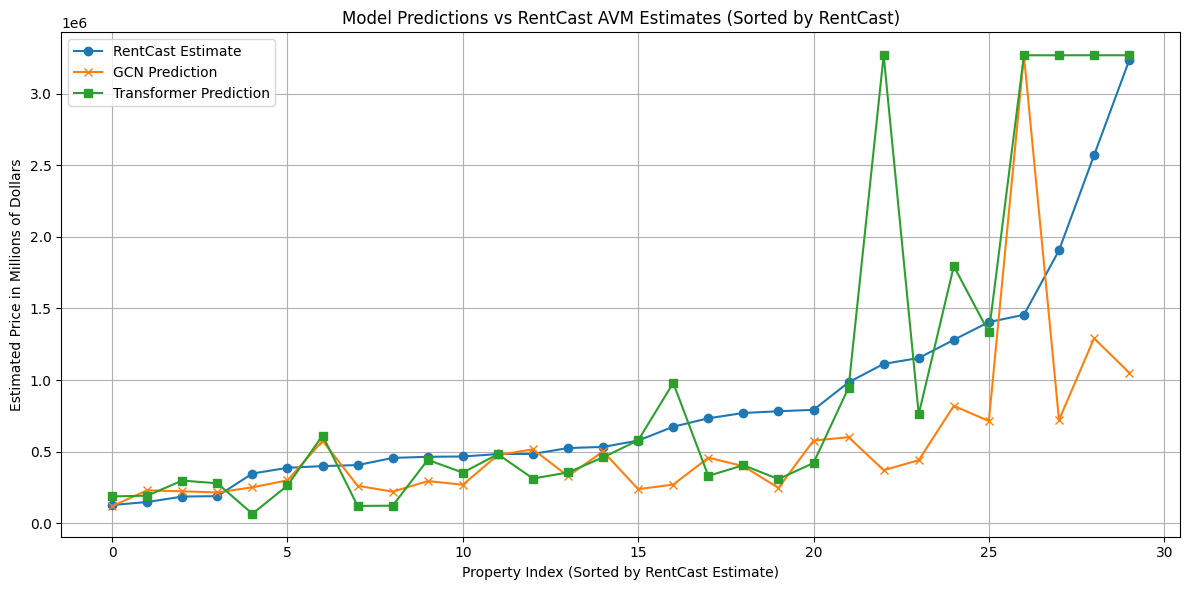

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset with RentCast estimates
df_input = pd.read_csv("rentcast_sample_with_estimates.csv")

# Initialize lists to store predictions
gcn_preds = []
transformer_preds = []

# Loop through each row and run predictions
for _, row in df_input.iterrows():
    house = {
        'latitude': row['latitude'],
        'longitude': row['longitude'],
        'bedrooms': row['bedrooms'],
        'bathrooms': row['bathrooms'],
        'squarefootage': row['squareFootage'],
        'lotsize': row.get('lotSize', 0.1),   # Default if missing
        'yearbuilt': row.get('yearBuilt', 2000),  # Default if missing
        'propertytype': row['propertyType'],
        'zipCode': str(row['zipCode'])  # ✅ Make sure zipCode is passed as string
    }

    # GCN with Zip Embedding
    gcn_price = predict_price(
        house,
        df_existing=df,
        trained_model=model,
        scaler=scaler,
        property_categories=property_categories,
        zip_code_to_idx=zip_code_to_idx
    )

    # Transformer (still doesn't use zip embedding)
    transformer_price = predict_price(
        house,
        df_existing=df,
        trained_model=transformer_model,
        scaler=scaler,
        property_categories=property_categories,
        zip_code_to_idx=zip_code_to_idx
    )

    gcn_preds.append(gcn_price)
    transformer_preds.append(transformer_price)

# Store predictions
df_input['GCN_Predicted'] = gcn_preds
df_input['Transformer_Predicted'] = transformer_preds

# Save results
df_input.to_csv("model_predictions_vs_rentcast.csv", index=False)
print("✅ Predictions saved to model_predictions_vs_rentcast.csv")

# Sort by RentCast estimates for better plotting
df_sorted = df_input.sort_values(by='rentcast_estimate').reset_index(drop=True)

# Plot sorted comparison
plt.figure(figsize=(12, 6))
plt.plot(df_sorted['rentcast_estimate'], label="RentCast Estimate", marker='o')
plt.plot(df_sorted['GCN_Predicted'], label="GCN Prediction", marker='x')
plt.plot(df_sorted['Transformer_Predicted'], label="Transformer Prediction", marker='s')
plt.legend()
plt.title("Model Predictions vs RentCast AVM Estimates (Sorted by RentCast)")
plt.xlabel("Property Index (Sorted by RentCast Estimate)")
plt.ylabel("Estimated Price in Millions of Dollars")
plt.grid(True)
plt.tight_layout()
plt.show()


In [53]:
files.download('model_predictions_vs_rentcast.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [54]:
df_input[['GCN_Predicted', 'Transformer_Predicted']].describe()


,GCN_Predicted,Transformer_Predicted
count,3.000000e+01,2.900000e+01
mean,9.746321e+05,1.055469e+06
std,9.018831e+05,1.206984e+06
min,9.441640e+04,7.183486e+04
25%,3.779436e+05,2.707627e+05
50%,7.361091e+05,4.298729e+05
75%,1.251138e+06,1.097028e+06
max,3.269017e+06,3.269017e+06


In [55]:
# Save GCN
torch.save(model.state_dict(), 'gcn_model.pth')

# Save Transformer GCN
torch.save(transformer_model.state_dict(), 'transformer_gcn_model.pth')


In [56]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Example paths (adjust as needed)
torch.save(model.state_dict(), '/content/drive/MyDrive/gcn_model.pth')
torch.save(transformer_model.state_dict(), '/content/drive/MyDrive/transformer_gcn_model.pth')


✅ GCN Correction: y = 0.6659 * prediction + 183151.31
✅ Transformer Correction: y = 0.4709 * prediction + 354114.82


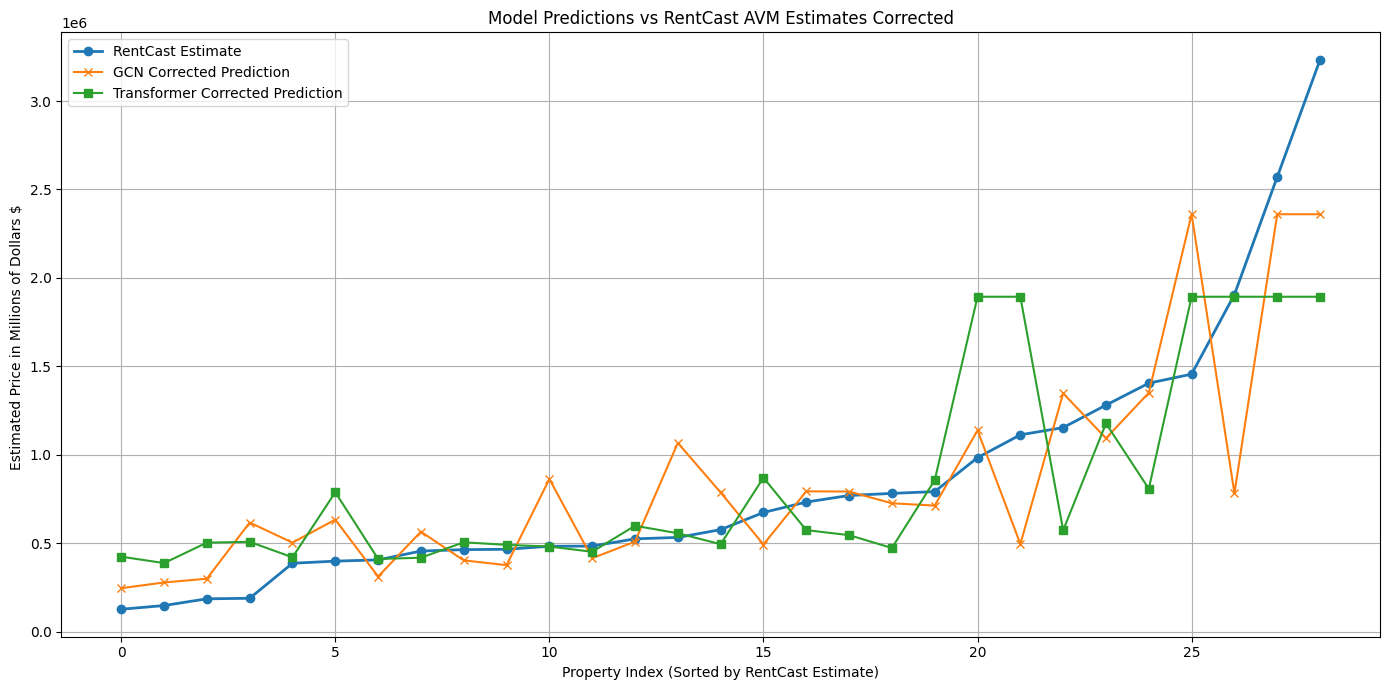

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Step 1: Load your predictions file
df = pd.read_csv("model_predictions_vs_rentcast.csv")

# Step 2: Drop rows with NaNs in critical columns
df = df.dropna(subset=['rentcast_estimate', 'GCN_Predicted', 'Transformer_Predicted'])

# Step 3: Sort by RentCast estimate
df_sorted = df.sort_values(by='rentcast_estimate').reset_index(drop=True)

# Step 4: Apply Linear Correction to GCN
X_gcn = df_sorted[['GCN_Predicted']]
y_true = df_sorted['rentcast_estimate']

gcn_corrector = LinearRegression().fit(X_gcn, y_true)
df_sorted['GCN_Predicted_Corrected'] = gcn_corrector.predict(X_gcn)

print(f"✅ GCN Correction: y = {gcn_corrector.coef_[0]:.4f} * prediction + {gcn_corrector.intercept_:.2f}")

# Step 5: Apply Linear Correction to Transformer
X_transformer = df_sorted[['Transformer_Predicted']]

transformer_corrector = LinearRegression().fit(X_transformer, y_true)
df_sorted['Transformer_Predicted_Corrected'] = transformer_corrector.predict(X_transformer)

print(f"✅ Transformer Correction: y = {transformer_corrector.coef_[0]:.4f} * prediction + {transformer_corrector.intercept_:.2f}")

# Step 6: Plot comparison
plt.figure(figsize=(14, 7))

plt.plot(df_sorted['rentcast_estimate'], label="RentCast Estimate", marker='o', linewidth=2)
#plt.plot(df_sorted['GCN_Predicted'], label="GCN Raw Prediction", linestyle='dashed', marker='x', alpha=0.6)
plt.plot(df_sorted['GCN_Predicted_Corrected'], label="GCN Corrected Prediction", marker='x')
#plt.plot(df_sorted['Transformer_Predicted'], label="Transformer Raw Prediction", linestyle='dashed', marker='s', alpha=0.6)
plt.plot(df_sorted['Transformer_Predicted_Corrected'], label="Transformer Corrected Prediction", marker='s')

plt.legend()
plt.title("Model Predictions vs RentCast AVM Estimates Corrected")
plt.xlabel("Property Index (Sorted by RentCast Estimate)")
plt.ylabel("Estimated Price in Millions of Dollars $ ")
plt.grid(True)
plt.tight_layout()
plt.show()
